In [1]:
import os
import scanpy as sc
from scipy import sparse
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import math
from utils import (
    GO_KEGG
)

analyze_all = 1

dataset_name = 'Cerebellum-PLATO' 
use_gene_emb = 'scGPT+ESM+pubmedbert' 

figure_path = "figures_" + dataset_name + '_demo_' + use_gene_emb +'/'
os.makedirs(figure_path, exist_ok=True)

if dataset_name == 'mouse_brain_coronal':
    base_spot_size = 1   
if dataset_name == 'Intestinal-villi':
    base_spot_size = 1 
if dataset_name == 'Cerebellum-PLATO':
    base_spot_size = 40   
    
adata_raw = sc.read_h5ad(figure_path+"adata_with_predict.h5ad")

print(adata_raw)
plt.rcdefaults()
plt.rcParams.update({
    "font.size": 20,           
})
adata_raw.uns[f"cluster_colors"] = ['#377EB8', "#095803", "#7E7C06", "#E88E8F"]  
ax = sc.pl.spatial(
    adata_raw,
    color="cluster",
    spot_size=base_spot_size,
    cmap="tab20",
    show=False,
    img_key=None)

plt.savefig(figure_path+"cluster_spatial.png", dpi=300, bbox_inches="tight")
plt.close() 

adata_with_predict = adata_raw.copy()
adata_with_predict.var_names = adata_with_predict.var['gene_name']
adata_with_predict.X = adata_with_predict.layers['predict']

adata_predict = sc.read_h5ad(figure_path+"adata_predict_union.h5ad") # adata_predict_union adata_predict_intersection
print(adata_predict)

/share/home/lijc/.conda/envs/SPgen_env/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/share/home/lijc/.conda/envs/SPgen_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 1677 × 1399
    obs: 'Spot_col', 'Spot_row', 'cluster', 'louvain1', 'louvain2'
    var: 'Genes', 'PG', 'Stable', 'highly_variable', 'gene_name'
    uns: 'cluster_colors', 'group_colors', 'hvg', 'log1p', 'louvain', 'louvain1_colors', 'louvain2_colors', 'louvain4_colors', 'neighbors', 'pca', 'spatial', 'test_gene_idx', 'train_gene_idx', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs', 'gene_emb'
    layers: 'GT', 'predict'
    obsp: 'connectivities', 'distances'
AnnData object with n_obs × n_vars = 1677 × 17230
    var: 'gene_name', 'uniprot_id', 'moranI'
    uns: 'moranI', 'spatial', 'spatial_neighbors'
    obsm: 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances'


In [2]:
import numpy as np
import scipy.sparse as sp
from sklearn.neighbors import NearestNeighbors

def _get_graph(adata, k=6, use_obsp=True):
    if use_obsp and 'connectivities' in adata.obsp:
        W = adata.obsp['connectivities'].copy()
        # 保证对称
        W = 0.5 * (W + W.T)
        return W.tocsr()
    
    if 'spatial' not in adata.obsm:
        raise ValueError("No 'connectivities' in adata.obsp and no 'spatial' in adata.obsm.")
    
    coords = adata.obsm['spatial']
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(coords)
    _, indices = nbrs.kneighbors(coords)
    
    n = coords.shape[0]
    rows, cols = [], []
    for i in range(n):
        for j in indices[i, 1:]:  
            rows.append(i)
            cols.append(j)
    
    data = np.ones(len(rows))
    W = sp.coo_matrix((data, (rows, cols)), shape=(n, n))
    W = 0.5 * (W + W.T)  # 对称
    return W.tocsr()


def _get_gene_vector(adata, g):

    if g not in adata.var_names:
        raise ValueError(f"{g} not found in adata.var_names")
    
    x = adata[:, g].X
    if sp.issparse(x):
        x = x.toarray().flatten()
    else:
        x = np.asarray(x).flatten()
    
    return x


def spatial_scores(adata, g, k=6, use_obsp=True):
    x = _get_gene_vector(adata, g)
    n = len(x)
    
    W = _get_graph(adata, k=k, use_obsp=use_obsp)
    
    d = np.array(W.sum(axis=1)).flatten()
    valid = d > 0
    x = x[valid]
    W = W[valid][:, valid]
    n = len(x)
    
    x_mean = x.mean()
    x_centered = x - x_mean
    
    W_coo = W.tocoo()
    i, j, w = W_coo.row, W_coo.col, W_coo.data
    

    # =========================
    # Moran's I
    # =========================
    S0 = w.sum()
    num = np.sum(w * x_centered[i] * x_centered[j])
    den = np.sum(x_centered ** 2) + 1e-8
    
    moran_i = (n / S0) * (num / den)
    
    # =========================
    # Geary's C
    # =========================
    num_c = np.sum(w * (x[i] - x[j])**2)
    
    geary_c = ((n - 1) / (2 * S0)) * (num_c / den)
    
    return moran_i, geary_c

adata_raw_ = adata_raw.copy()
adata_raw_.var_names = adata_with_predict.var_names.copy()

raw_MoranI, raw_GearyC, SPgen_MoranI, SPgen_GearyC = [], [], [], []
for g in adata_raw_.var_names:
    moran_i, geary_c = spatial_scores(adata_raw_, g)
    raw_MoranI.append(moran_i)
    raw_GearyC.append(geary_c)
    
    moran_i, geary_c = spatial_scores(adata_with_predict, g)
    SPgen_MoranI.append(moran_i)
    SPgen_GearyC.append(geary_c)    




/tmp/ipykernel_110496/877939749.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([new_labels.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])


MoranI 5.117518682034403e-224
GearyC 3.1522199247803702e-230


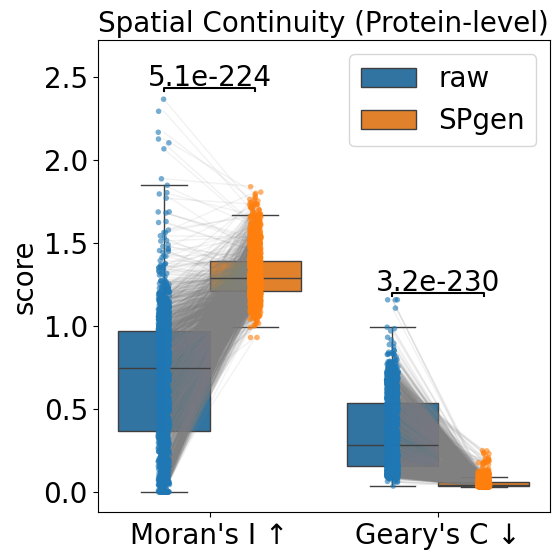

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 20,            
    "axes.titlesize": 20,       
    "axes.labelsize": 20,       
    "xtick.labelsize": 20,      
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "figure.titlesize": 20,
    "figure.autolayout": True,
})


df = pd.DataFrame({
    "raw_MoranI": raw_MoranI,
    "SPgen_MoranI": SPgen_MoranI,
    "raw_GearyC": raw_GearyC,
    "SPgen_GearyC": SPgen_GearyC,
})

df_long = pd.melt(df, var_name="metric_method", value_name="score")
df_long["metric"] = df_long["metric_method"].apply(lambda x: x.split("_")[1])
df_long["method"] = df_long["metric_method"].apply(lambda x: x.split("_")[0])
df_long["id"] = np.tile(np.arange(len(df)), 4)

plt.figure(figsize=(6,6))

ax = sns.boxplot(
    data=df_long,
    x="metric",
    y="score",
    hue="method",
    showfliers=False
)

sns.stripplot(
    data=df_long,
    x="metric",
    y="score",
    hue="method",
    dodge=True,
    jitter=0.05,
    alpha=0.6,
    size=4,
    ax=ax
)

new_labels = {
    "MoranI": "Moran's I ↑",
    "GearyC": "Geary's C ↓"
}
ax.set_xticklabels([new_labels.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
plt.xlabel('') 

def add_pval(ax, x1, x2, y, text):
    ax.plot([x1, x1, x2, x2], [y, y+0.02, y+0.02, y], lw=1.5, c='black')
    ax.text((x1+x2)/2, y+0.03, text, ha='center', fontsize=20)

metrics = ["MoranI", "GearyC"]
from scipy.stats import wilcoxon
for i, m in enumerate(metrics):
    raw = df['raw_' + m]
    spg = df["SPgen_" + m]

    stat, p = wilcoxon(raw, spg)
    print(m, p)
    y_max = df_long[df_long["metric"]==m]["score"].max()

    add_pval(ax, i-0.2, i+0.2, y_max*1.02, str(f"{p:.2g}"))
    
y_max_all = df_long["score"].max()
ax.set_ylim(top=y_max_all * 1.15)

# paired lines
xticks = ax.get_xticks()
offset = 0.2
for i, m in enumerate(metrics):
    sub = df_long[df_long["metric"] == m]
    # pivot 成 paired
    pivot = sub.pivot(index="id", columns="method", values="score")
    for _, row in pivot.iterrows():
        if not np.isnan(row["raw"]) and not np.isnan(row["SPgen"]):
            x1 = xticks[i] - offset
            x2 = xticks[i] + offset
            ax.plot(
                [x1, x2],
                [row["raw"], row["SPgen"]],
                color="gray",
                alpha=0.1,
                linewidth=1
            )
            
            
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2])
plt.title("Spatial Continuity (Protein-level)")
plt.tight_layout()
plt.show()

0.09374065 0.20279382
0.0017313112 0.0039663534


/tmp/ipykernel_110496/2843382407.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_means = df.groupby("label").mean()
/tmp/ipykernel_110496/2843382407.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  within = df.groupby("label").apply(
/tmp/ipykernel_110496/2843382407.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this 

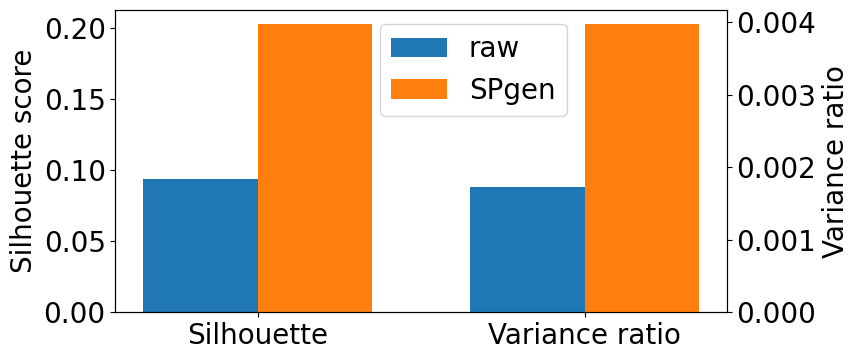

In [4]:
from sklearn.metrics import silhouette_score

X_gt = adata_with_predict.layers["GT"]
X_pred = adata_with_predict.layers["predict"]
labels = adata_with_predict.obs["cluster"]


def cluster_var_ratio(X, labels):
    df = pd.DataFrame(X)
    df["label"] = labels.values

    cluster_means = df.groupby("label").mean()
    global_mean = df.iloc[:, :-1].mean()

    # between-cluster variance
    between = ((cluster_means - global_mean) ** 2).sum().sum()

    # within-cluster variance
    within = df.groupby("label").apply(
        lambda x: ((x.iloc[:, :-1] - x.iloc[:, :-1].mean()) ** 2).sum().sum()
    ).sum()

    return between / within

sil_gt = silhouette_score(X_gt, labels)
sil_pred = silhouette_score(X_pred, labels)
print(sil_gt, sil_pred)

v_gt = cluster_var_ratio(X_gt, labels)
v_pred = cluster_var_ratio(X_pred, labels)
print(v_gt, v_pred)


df_plot = pd.DataFrame({
    "metric": ["Silhouette", "Variance ratio"],
    "raw": [sil_gt, v_gt],
    "SPgen": [sil_pred, v_pred]
})

x = np.arange(len(df_plot))
width = 0.35

fig, ax1 = plt.subplots(figsize=(9,4))
ax2 = ax1.twinx()

ax1.bar(x[0] - width/2, df_plot.loc[0, "raw"], width)
ax1.bar(x[0] + width/2, df_plot.loc[0, "SPgen"], width)

ax2.bar(x[1] - width/2, df_plot.loc[1, "raw"], width)
ax2.bar(x[1] + width/2, df_plot.loc[1, "SPgen"], width)

# ===== labels =====
ax1.set_ylabel("Silhouette score")
ax2.set_ylabel("Variance ratio")

ax1.set_xticks(x)
ax1.set_xticklabels(df_plot["metric"])


colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
c_raw = colors[0]
c_spgen = colors[1]
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=c_raw, label="raw"),
    Patch(facecolor=c_spgen, label="SPgen")
]

ax1.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(0.41, 1.0),  )
plt.tight_layout()
plt.show()

In [5]:
adata_predict.obs_names = adata_with_predict.obs_names
adata_predict.obs['cluster'] = adata_with_predict.obs['cluster']

sc.tl.rank_genes_groups(
    adata_predict,
    groupby='cluster',   
    method='wilcoxon',         
    use_raw=False              
)

cluster_top_dict = {}
for group in adata_predict.obs['cluster'].cat.categories:
    cluster_genes = sc.get.rank_genes_groups_df(adata_predict, group=group)
    cluster_top = cluster_genes.sort_values('scores', ascending=False)
    cluster_top_dict[group] = cluster_top   

/share/home/lijc/.conda/envs/SPgen_env/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/share/home/lijc/.conda/envs/SPgen_env/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/share/home/lijc/.conda/envs/SPgen_env/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/share/home/lijc/.conda/envs/SPgen_env/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


In [6]:
topk = 200
bg = list(adata_predict.var['gene_name'])

for group in cluster_top_dict.keys():
    cluster_top = cluster_top_dict[group]
    cluster_top_p = cluster_top['names'].values[:topk]
    cluster_top_g = (adata_predict.var.loc[cluster_top_p, 'gene_name'].values)

    GO_KEGG(gene_list=list(cluster_top_g), background=bg, figure_path=figure_path, save_name='testall_union_cluster_'+group+'_top'+str(topk), organism='mouse')

    sc.pl.spatial(adata_predict, color=cluster_top_p[:25], ncols=5, spot_size=base_spot_size, cmap="plasma", vmin="p2", vmax="p98", img_key=None, show=False)
    fig = plt.gcf()
    for ax in fig.axes:
        ax.set_yticks([])       
        ax.set_yticklabels([])  
        ax.set_ylabel('')  
        ax.tick_params(axis='both', labelsize=25)
        title = ax.get_title()
        ax.set_title(title, fontsize=30)
        ax.set_xlabel("")
        for spine in ax.spines.values():
            spine.set_visible(False)       
    plt.savefig(figure_path+'/Enrichr_testall_union_cluster_'+group+'_top'+str(topk)+'/genes.png', dpi=100, bbox_inches='tight')
    plt.close()
    

/share/home/lijc/.local/lib/python3.9/site-packages/gseapy/plot.py:1351: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  dot.fig.savefig(ofname, bbox_inches="tight", dpi=300)


Figure saved to figures_Cerebellum-PLATO_demo_scGPT+ESM+pubmedbert/Enrichr_testall_union_cluster_Fiber_tracts_top200/GO_Biological_Process_2021.mouse.enrichr.png


/tmp/ipykernel_110496/20823609.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(figure_path+'/Enrichr_testall_union_cluster_'+group+'_top'+str(topk)+'/genes.png', dpi=100, bbox_inches='tight')
/share/home/lijc/.local/lib/python3.9/site-packages/gseapy/plot.py:1351: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  dot.fig.savefig(ofname, bbox_inches="tight", dpi=300)


Figure saved to figures_Cerebellum-PLATO_demo_scGPT+ESM+pubmedbert/Enrichr_testall_union_cluster_Granular_layer_top200/GO_Biological_Process_2021.mouse.enrichr.png


/tmp/ipykernel_110496/20823609.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(figure_path+'/Enrichr_testall_union_cluster_'+group+'_top'+str(topk)+'/genes.png', dpi=100, bbox_inches='tight')
/share/home/lijc/.local/lib/python3.9/site-packages/gseapy/plot.py:1351: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  dot.fig.savefig(ofname, bbox_inches="tight", dpi=300)


Figure saved to figures_Cerebellum-PLATO_demo_scGPT+ESM+pubmedbert/Enrichr_testall_union_cluster_Lateral_recess_top200/GO_Biological_Process_2021.mouse.enrichr.png


/tmp/ipykernel_110496/20823609.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(figure_path+'/Enrichr_testall_union_cluster_'+group+'_top'+str(topk)+'/genes.png', dpi=100, bbox_inches='tight')
/share/home/lijc/.local/lib/python3.9/site-packages/gseapy/plot.py:1351: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  dot.fig.savefig(ofname, bbox_inches="tight", dpi=300)


Figure saved to figures_Cerebellum-PLATO_demo_scGPT+ESM+pubmedbert/Enrichr_testall_union_cluster_Molecular_layer_top200/GO_Biological_Process_2021.mouse.enrichr.png


/tmp/ipykernel_110496/20823609.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(figure_path+'/Enrichr_testall_union_cluster_'+group+'_top'+str(topk)+'/genes.png', dpi=100, bbox_inches='tight')
